Go to this link, at your lat long, copy the url at the bottom and lazy load it here: http://thredds.northwestknowledge.net:8080/thredds/ncss/grid/agg_terraclimate_tmin_1958_CurrentYear_GLOBE.nc/dataset.html

In [3]:
import geopandas as gpd
import rioxarray
import xarray as xr
from geojson import Feature, FeatureCollection


In [ ]:
ds_min = xr.open_dataset("http://thredds.northwestknowledge.net:8080/thredds/dodsC/agg_terraclimate_tmin_1958_CurrentYear_GLOBE.nc")
ds_max = xr.open_dataset("http://thredds.northwestknowledge.net:8080/thredds/dodsC/agg_terraclimate_tmax_1958_CurrentYear_GLOBE.nc")


C:\Users\hiban\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xarray\backends\api.py:577: RuntimeWarning: 'scipy' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
C:\Users\hiban\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xarray\backends\api.py:577: RuntimeWarning: 'scipy' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


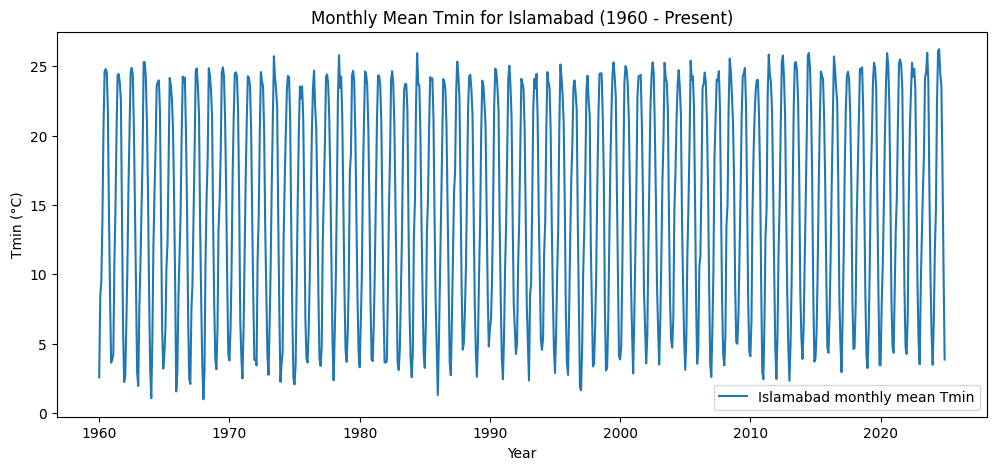

C:\Users\hiban\AppData\Local\Temp\ipykernel_16748\2441231481.py:48: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  tmin_annual = tmin_monthly_series.resample('Y').mean()


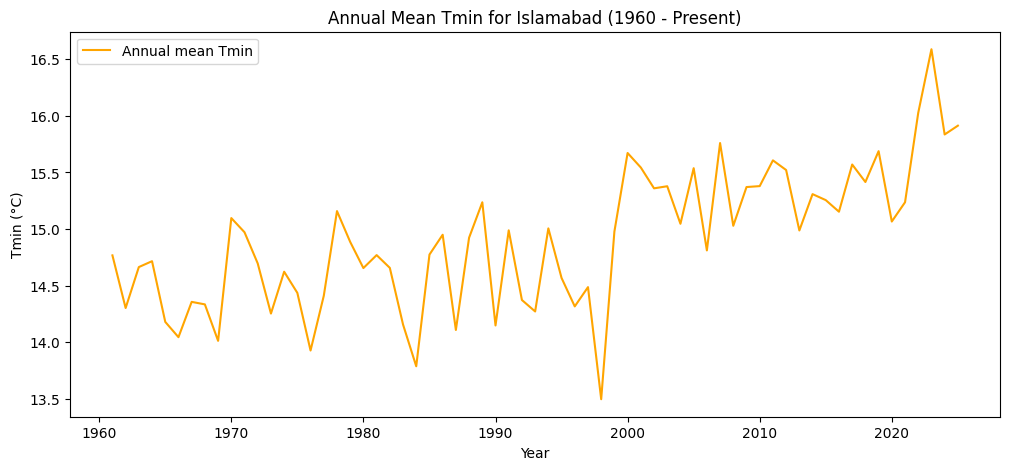

In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt


# Define Islamabad bounding box
lat_min, lat_max = 33, 34
lon_min, lon_max = 72, 74

# Subset spatially
tmin_isl = ds_min['tmin'].sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))
tmax_isl = ds_max['tmax'].sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))

# -------------------------------
# 3. Subset time: 1960 onward
# -------------------------------
tmin_isl = tmin_isl.sel(time=slice('1960-01-01', None))
tmax_isl = tmax_isl.sel(time=slice('1960-01-01', None))

# -------------------------------
# 4. Compute monthly average over all grid points
# -------------------------------
tmin_monthly = tmin_isl.mean(dim=['lat','lon'])
tmax_monthly = tmax_isl.mean(dim=['lat','lon'])

# -------------------------------
# 5. Convert to pandas for easier handling
# -------------------------------
tmin_monthly_series = tmin_monthly.to_pandas()
tmax_monthly_series = tmax_monthly.to_pandas()

# -------------------------------
# 6. Plot monthly Tmin time series
# -------------------------------
plt.figure(figsize=(12,5))
plt.plot(tmin_monthly_series.index, tmin_monthly_series, label='Islamabad monthly mean Tmin')
plt.xlabel("Year")
plt.ylabel("Tmin (°C)")
plt.title("Monthly Mean Tmin for Islamabad (1960 - Present)")
plt.legend()
plt.show()

# -------------------------------
# 7. Optional: Compute annual mean
# -------------------------------
tmin_annual = tmin_monthly_series.resample('Y').mean()

plt.figure(figsize=(12,5))
plt.plot(tmin_annual.index, tmin_annual, label='Annual mean Tmin', color='orange')
plt.xlabel("Year")
plt.ylabel("Tmin (°C)")
plt.title("Annual Mean Tmin for Islamabad (1960 - Present)")
plt.legend()
plt.show()


In [4]:
i9 = Feature(
    geometry={
        "type": "Polygon",
        "coordinates": [
            [
                [73.05935121467046, 33.66889377550622],
                [73.04114684833641, 33.65927102811309],
                [73.05150463578407, 33.64541818656263],
                [73.06975323519342, 33.65496814971216],
                [73.05935121467046, 33.66889377550622]
            ]
        ]
    },
    properties={}
)

muhrain = Feature(
    geometry={
        "type": "Polygon",
        "coordinates": [
            [
                [73.18383711404763, 33.6771543555071],
                [73.18224812444514, 33.67293670814887],
                [73.18338366677189, 33.66514216120249],
                [73.19462910718788, 33.667818993929714],
                [73.19611047129129, 33.6732827349585],
                [73.19091831316203, 33.67711190653568],
                [73.18383711404763, 33.6771543555071]
            ]
        ]
    },
    properties={}
)

collection = FeatureCollection([i9, muhrain])

gdf = gpd.GeoDataFrame.from_features(collection["features"])
gdf.set_crs(epsg=4326, inplace=True)
gdf


,geometry
0,"POLYGON ((73.05935 33.66889, 73.04115 33.65927..."
1,"POLYGON ((73.18384 33.67715, 73.18225 33.67294..."


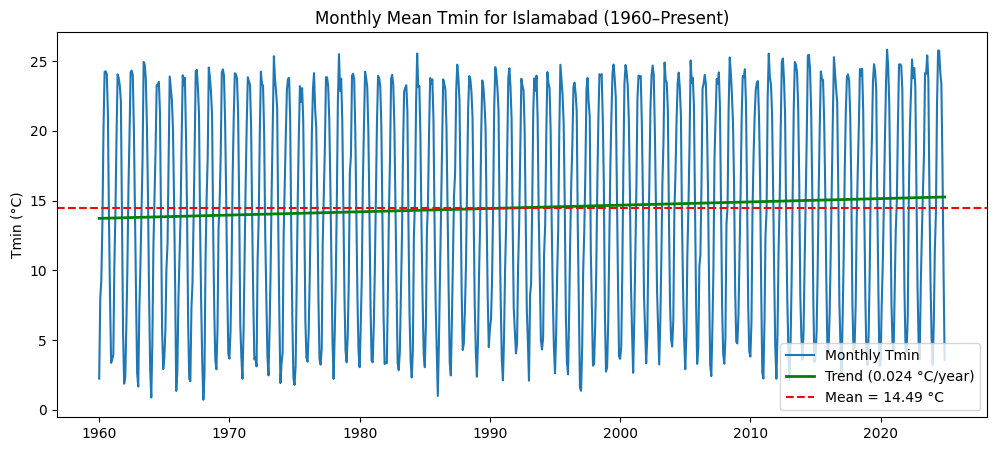

C:\Users\hiban\AppData\Local\Temp\ipykernel_17608\145547782.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  tmin_annual = tmin_monthly_series.resample('Y').mean()


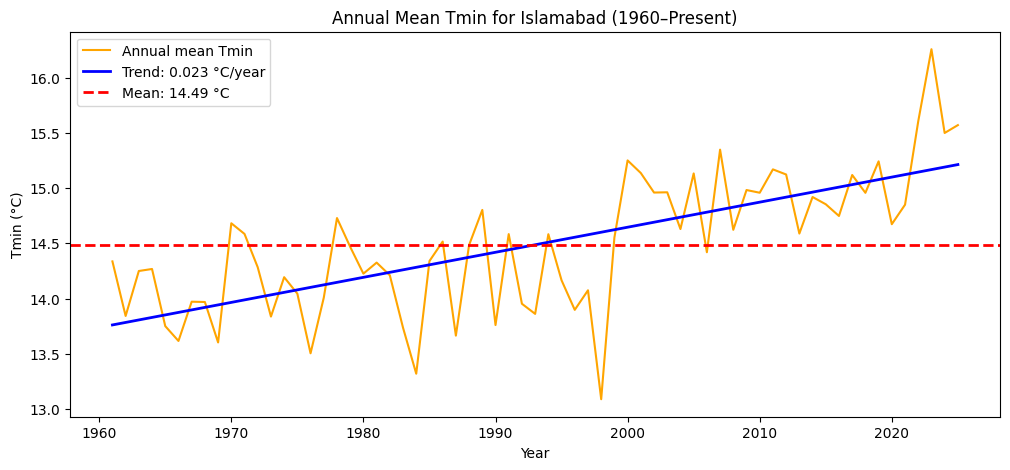

: 

In [ ]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

x = tmin_monthly_series.index.year + tmin_monthly_series.index.dayofyear/365
y = tmin_monthly_series.values

slope, intercept, r_value, p_value, std_err = linregress(x, y)

trend = intercept + slope * x

plt.figure(figsize=(12,5))
plt.plot(tmin_monthly_series.index, tmin_monthly_series, label='Monthly Tmin')
plt.plot(tmin_monthly_series.index, trend, color='green', linewidth=2,
         label=f"Trend ({slope:.3f} °C/year)")

plt.axhline(y=y.mean(), color='red', linestyle='--', label=f"Mean = {y.mean():.2f} °C")
plt.title("Monthly Mean Tmin for Islamabad (1960–Present)")
plt.ylabel("Tmin (°C)")
plt.legend()
plt.show()




tmin_annual = tmin_monthly_series.resample('Y').mean()

# Convert index to numeric years
x = tmin_annual.index.year
y = tmin_annual.values

# Compute linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
trend = intercept + slope * x
mean_value = np.mean(y)

# Plot
plt.figure(figsize=(12,5))
plt.plot(tmin_annual.index, y, label='Annual mean Tmin', color='orange')
plt.plot(tmin_annual.index, trend, color='blue', linewidth=2,
         label=f'Trend: {slope:.3f} °C/year')
plt.axhline(mean_value, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {mean_value:.2f} °C')

plt.title("Annual Mean Tmin for Islamabad (1960–Present)")
plt.xlabel("Year")
plt.ylabel("Tmin (°C)")
plt.legend()
plt.show()